In [23]:
import numpy as np
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Geod

from track_utils import \
    plot_tracks, \
    plot_timeseries, \
    _get_track_segment, \
    _get_lonslats, \
    load_single_era5_track, \
    decode_360_time
from run_analogues import \
    cases, \
    settings, \
    reload_analogues, \
    output_dir

plot_dir = output_dir / 'plots'

# cases_to_use = ['Arwen', 'GreatStorm', 'Ophelia', 'Martin', 'Eunice', 'NorthSea']
# setting = 'vn1-300'
# plot_extent = [-60, 10, 40, 70]
# vorthres = 8    # for subsetting to extremes

# cases_to_use = ['Jul2021', 'Jul2012']
# setting = 'cols'
# plot_extent = [-40, 30, 25, 65]
# vorthres = 14    # for subsetting to extremes (vorticity values much higher at 250hPa!)

# cases_to_use = ['Oct2017jr', 'Ciaran']
# setting = 'drws'
# plot_extent = [-60, 10, 30, 60]
# vorthres = 10    # for subsetting to extremes

cases_to_use = ['Andrea', 'Julia', 'Vaia', 'Daniel', 'Apollo', 'Ianos']
setting = 'med1'
plot_extent = [-10, 40, 25, 50]
vorthres = 8    # for subsetting to extremes
# cases_to_use = ['Vaia']
# setting = 'medvaia'
# plot_extent = [-10, 40, 25, 50]
# vorthres = 8    # for subsetting to extremes
# cases_to_use = ['Daniel']
# setting = 'meddaniel'
# plot_extent = [5, 45, 30, 55]
# vorthres = 8    # for subsetting to extremes

# cases_to_use = ['Groundhog', 'Franklin']
# setting = 'drws'
# plot_extent = [-110, -60, 20, 60]
# vorthres = 12    # for subsetting to extremes

# cases_to_use = ['Capella', 'DDay']
# setting = 'drws'
# plot_extent = [-60, 40, 30, 70]
# vorthres = 8    # for subsetting to extremes


# These functions assume tracks are loaded into nested dicts of the form
# {case: {exp_label: {mem_label: {track_id: track}}}


def summarise_nested_dicts(d, level=0, out=''):
    """
    Print summary of nested track dicts.
    Note: Go up to level before last dict, then print number
    of tracks in last dict.
    """
    for k, v in d.items():
        outnew = f'{out}{k}:'
        if isinstance(v, dict):
            if v and isinstance(next(iter(v.values())), dict):
                summarise_nested_dicts(v, level+1, outnew)
            else:
                print(f'{outnew} [{len(v)} items]')


def subset_extremes(tracks, vorthres=8):
    """
    Subset a nested track dict to just the tracks exceding
    a vorticity threshold somewhere along the track.
    """
    out = {case: {exp_label: {mem_label: {k: v for k, v in memtracks.items() if np.nanmax(v['relative_vorticity'].values) > vorthres}
                              for mem_label, memtracks in exptracks.items()}
                  for exp_label, exptracks in casetracks.items()}
            for case, casetracks in tracks.items()}
    # Remove any empty members
    out = {case: {exp_label: {mem_label: memtracks for mem_label, memtracks in exptracks.items() if memtracks}
                  for exp_label, exptracks in casetracks.items()}
            for case, casetracks in out.items()}
    return out


def flatten_mem_labels(tracks):
    """
    Merge all track mem_labels to parent exp_label.
    """
    out = {}
    for case, casetracks in tracks.items():
        out[case] = {}
        for exp_label, exptracks in casetracks.items():
            out[case][exp_label] = {}
            for mem_label, memtracks in exptracks.items():
                out[case][exp_label].update(memtracks)
    return out

Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20112012_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20112012_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20182019_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_mar-oct2023_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20212022_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_mar-oct2020_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc


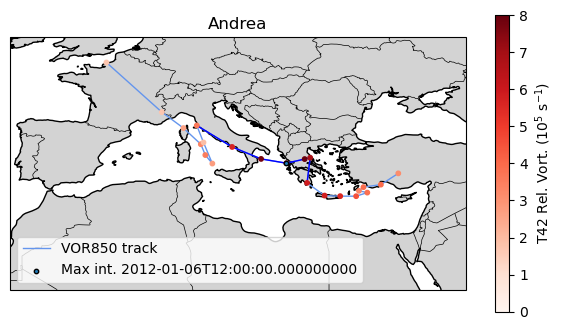

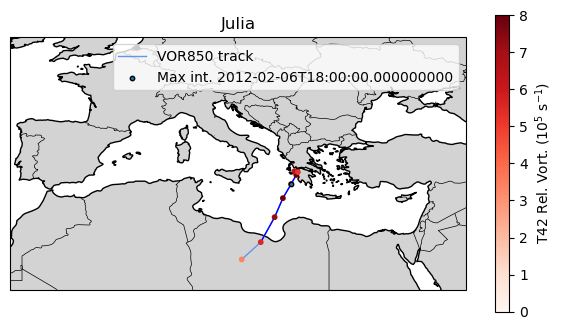

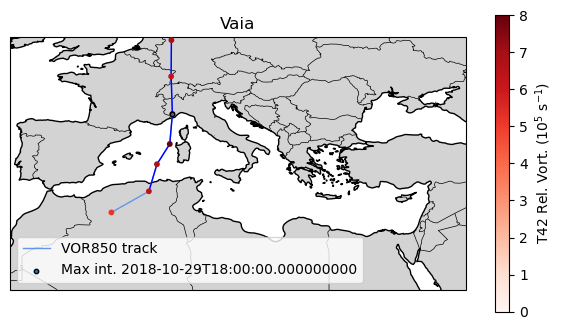

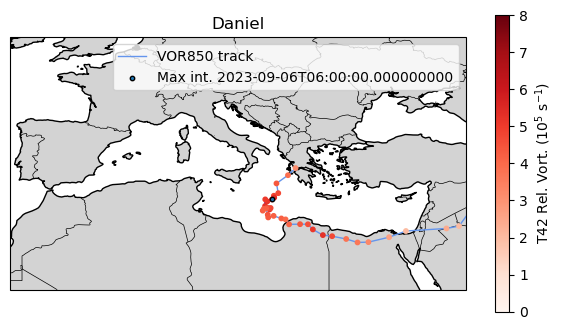

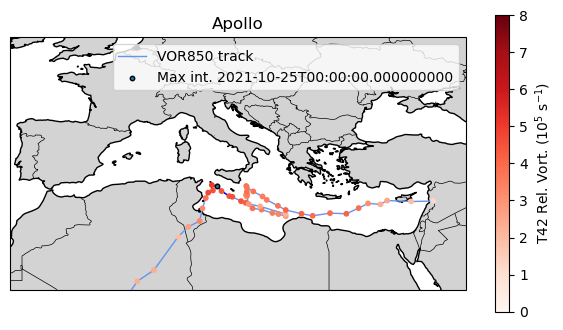

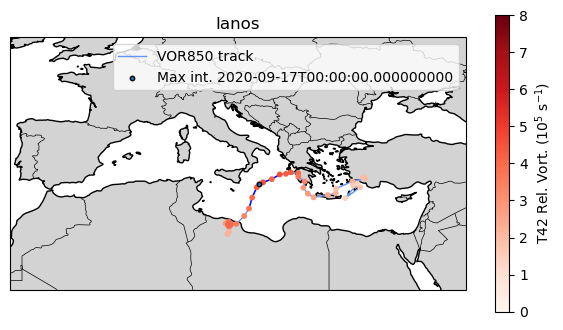

In [24]:
# Sanity plot of target_tracks

for case in cases_to_use:
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    ax = plot_tracks({1: target_track}, color='cornflowerblue', trackvar=cases[case]['trackvar'])
    segment = _get_track_segment(target_track, **settings[setting])
    plot_tracks({1: segment}, ax=ax, color='blue', show_intensity=False)
    ax.set_extent(plot_extent)
    ax.legend()
    ax.set_title(case)
    ax.figure.tight_layout()
    ax.figure.savefig(fdir / f'{case}_{setting}_sanity-plot.png')

In [25]:
# Gather all analogue and candidate tracks
tracks = {
    case: {
        exp_label: reload_analogues(case, exp_label+'*', setting) for exp_label in ['ERA5', 'PRESENT', 'FUTURE']
    } for case in cases_to_use
}
tracks_ext = subset_extremes(tracks, vorthres=vorthres)
ctracks = {
    case: {
        exp_label: reload_analogues(case, exp_label+'*', setting, get_candidates=True) for exp_label in ['ERA5', 'PRESENT', 'FUTURE']
    } for case in cases_to_use
}
ctracks_ext = subset_extremes(ctracks, vorthres=vorthres)

LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/ERA5_Andrea_analogues_med1.nc
LOAD_TRACKS: Found 10 tracks
RELOAD_ANALOGUES(Andrea, ERA5*, med1, analogues): Loaded 1 files, 10 tracks
LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/PRESENTm7_Andrea_analogues_med1.nc
LOAD_TRACKS: Found 14 tracks
LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/PRESENTm14_Andrea_analogues_med1.nc
LOAD_TRACKS: Found 9 tracks
LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/PRESENTm15_Andrea_analogues_med1.nc
LOAD_TRACKS: Found 9 tracks
LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/PRESENTm10_Andrea_analogues_med1.nc
LOAD_TRACKS: Found 8 tracks
LOAD_TRACKS: Loading file /home/users/bjharvey/workspaces/medcyclones/track-analogues/data/Andrea/PRESENTm24_Andrea_ana

Andrea candidates:
-- ERA5 All: 162 (162.0) Extreme: 2 (2.0)
-- PRESENT All: 7271 (181.775) Extreme: 147 (3.675)
-- FUTURE All: 5873 (146.825) Extreme: 162 (4.05)
Andrea analogues:
-- ERA5 All: 10 (10.0) Extreme: 0 (0.0)
-- PRESENT All: 451 (11.275) Extreme: 16 (0.4)
-- FUTURE All: 405 (10.125) Extreme: 13 (0.325)
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20112012_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Julia candidates:
-- ERA5 All: 139 (139.0) Extreme: 3 (3.0)
-- PRESENT All: 5671 (141.775) Extreme: 153 (3.825)
-- FUTURE All: 4370 (109.25) Extreme: 147 (3.675)
Julia analogues:
-- ERA5 All: 1 (1.0) Extreme: 0 (0.0)
-- PRESENT All: 51 (1.275) Extreme: 3 (0.075)
-- FUTURE All: 36 (0.9) Extreme: 8 (0.2)
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20112012_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Vaia candidates:
-- ERA5 All: 46 (46.0) Extreme: 0 (0.0)
-- PRESENT All: 2016 (50.

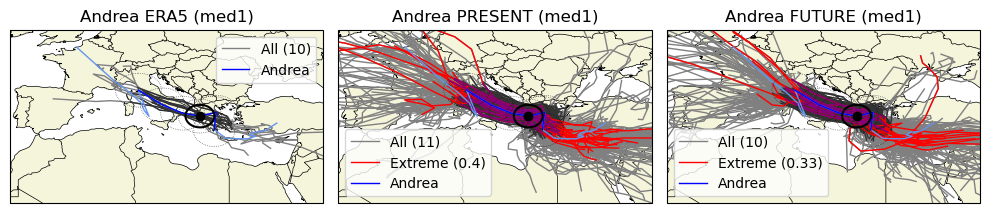

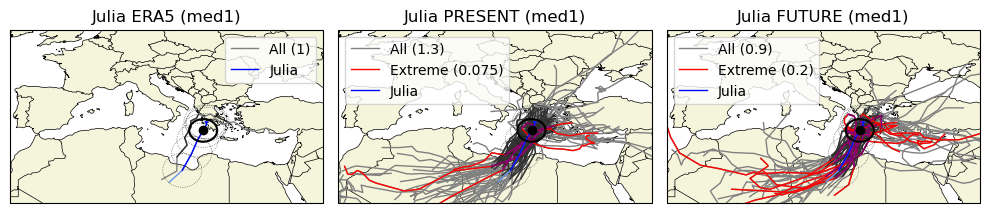

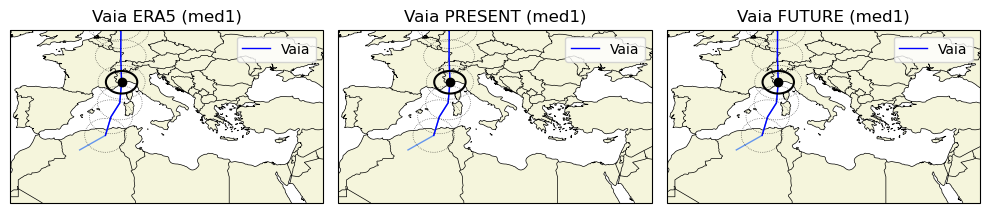

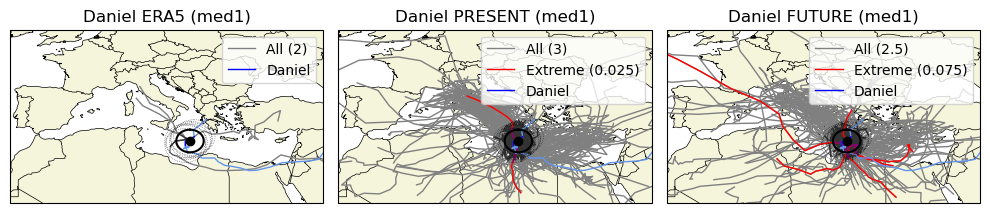

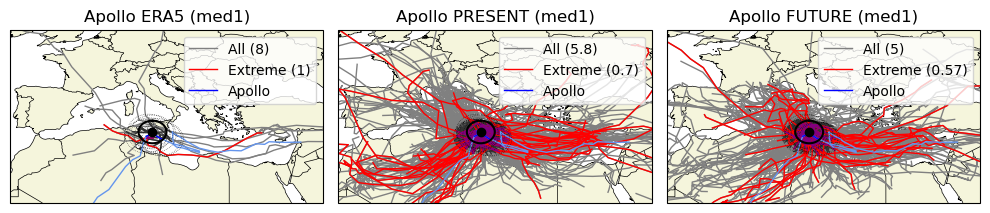

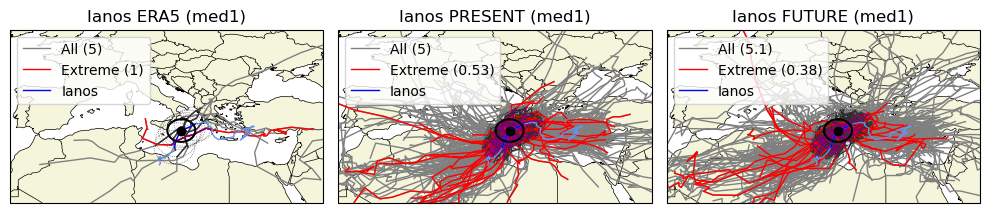

In [26]:
# Plot maps

def _make_circle_lonlats(target_lon, target_lat, radiuskm):
    geod = Geod(ellps="WGS84")
    azimuths = np.linspace(0, 360, 100)
    lons, lats = geod.fwd(
        np.full_like(azimuths, target_lon),
        np.full_like(azimuths, target_lat),
        azimuths,
        np.full_like(azimuths, 1e3*radiuskm)
    )[:2]
    return lons, lats


def plot_map_panel(target_track, tracks, tracks_ext, ax=None, nmems=1):
    # Plot tracks
    tracksegments = {k: _get_track_segment(v, **settings[setting]) for k, v in tracks.items()}
    ax = plot_tracks(tracks, color='0.5', show_intensity=False, label=f'All ({len(tracks)/nmems:.2g})', ax=ax)
    ax = plot_tracks(tracksegments, color='0.2', show_intensity=False, ax=ax)
    ax = plot_tracks(tracks_ext, color='r', show_intensity=False, label=f'Extreme ({len(tracks_ext)/nmems:.2g})', ax=ax)
    tracksegments_ext = {k: _get_track_segment(v, **settings[setting]) for k, v in tracks_ext.items()}
    ax = plot_tracks(tracksegments_ext, color='purple', show_intensity=False, ax=ax)
    # Overlay target_track
    segment = _get_track_segment(target_track, **settings[setting])
    plot_tracks({1: target_track}, ax=ax, color='cornflowerblue', show_intensity=False)
    ax = plot_tracks({1: segment}, ax=ax, color='blue', show_intensity=False, label=case)
    target_lon, target_lat = [l[settings[setting]['seg_len_before']] for l in _get_lonslats(segment)]
    ax.plot(target_lon, target_lat, transform=ccrs.PlateCarree(), color='k', marker='o', zorder=100)
    ax.plot(*_make_circle_lonlats(target_lon, target_lat, settings[setting]['candidate_distance']),
            transform=ccrs.PlateCarree(), color='k', zorder=100)
    for i in range(settings[setting]['seg_len_before'] + settings[setting]['seg_len_after'] + 1):
        target_lon, target_lat = [l[i] for l in _get_lonslats(segment)]
        ax.plot(*_make_circle_lonlats(target_lon, target_lat, settings[setting]['analogue_distance']),
                transform=ccrs.PlateCarree(), color='k', alpha=0.7, zorder=100, linewidth=0.5, linestyle=':')
    ax.legend()
    return ax


def plot_analogue_maps(case, tracks, tracks_ext):
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    fig, axs = plt.subplots(1, 3, figsize=[10, 4], subplot_kw={'projection': ccrs.PlateCarree()})
    ax = axs[0]
    plot_map_panel(target_track, tracks['ERA5'], tracks_ext['ERA5'], ax=ax, nmems=1)
    ax.set_title(f'{case} ERA5 ({setting})')
    ax = axs[1]
    plot_map_panel(target_track, tracks['PRESENT'], tracks_ext['PRESENT'], ax=ax, nmems=40)
    ax.set_title(f'{case} PRESENT ({setting})')
    ax = axs[2]
    plot_map_panel(target_track, tracks['FUTURE'], tracks_ext['FUTURE'], ax=ax, nmems=40)
    ax.set_title(f'{case} FUTURE ({setting})')
    for ax in axs.flatten():
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='beige')
        #ax.add_feature(cfeature.OCEAN, facecolor='lightcyan')
        ax.set_extent(plot_extent)
    fig.tight_layout()
    return fig, axs

ftracks = flatten_mem_labels(tracks)
ftracks_ext = flatten_mem_labels(tracks_ext)
fctracks = flatten_mem_labels(ctracks)
fctracks_ext = flatten_mem_labels(ctracks_ext)
for case in cases_to_use:
    print(f'{case} candidates:')
    for exp_label in ftracks[case].keys():
        n = len(fctracks[case][exp_label])
        n_ext = len(fctracks_ext[case][exp_label])
        print(f'-- {exp_label} '\
              f'All: {n} ({n / (1 if exp_label == 'ERA5' else 40)}) '\
              f'Extreme: {n_ext} ({n_ext / (1 if exp_label == 'ERA5' else 40)})')
    print(f'{case} analogues:')
    for exp_label in ftracks[case].keys():
        n = len(ftracks[case][exp_label])
        n_ext = len(ftracks_ext[case][exp_label])
        print(f'-- {exp_label} '\
              f'All: {n} ({n / (1 if exp_label == 'ERA5' else 40)}) '\
              f'Extreme: {n_ext} ({n_ext / (1 if exp_label == 'ERA5' else 40)})')
    fig, axs = plot_analogue_maps(case, ftracks[case], ftracks_ext[case])
    fig.savefig(fdir / f'{case}_{setting}_analogue-maps.png')


 Arwen
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20212022_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
relative_vorticity
wind_speed_10m
precipitation_flux
month
number
4 21 [ 3.5  5.5  7.5  9.5 11.5 13.5 15.5 17.5 19.5 21.5]
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20212022_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
relative_vorticity
wind_speed_10m
precipitation_flux
month
number
0 5 [-0.5  0.5  1.5  2.5  3.5  4.5  5.5]


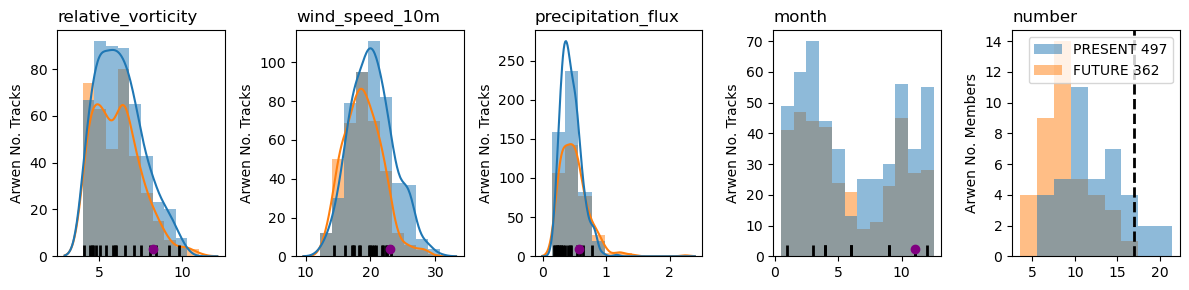

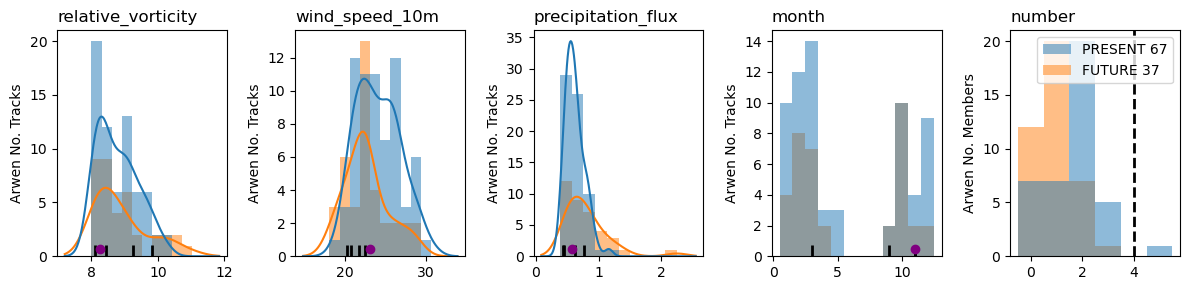

In [9]:
# Plot histograms

def get_stats(tracks):
    """
    Return key metrics for this set of tracks.
    """
    varnames = ['relative_vorticity', 'wind_speed_10m', 'precipitation_flux', 'month']
    stats = {}
    for case, casetracks in tracks.items():
        stats[case] = {}
        for exp_label, exptracks in casetracks.items():
            stats[case][exp_label] = {}
            for mem_label, memtracks in exptracks.items():
                stats[case][exp_label][mem_label] = {k: [] for k in varnames}
                for trackid, track in memtracks.items():
                    segment = _get_track_segment(track, **settings[setting])
                    for k, v in stats[case][exp_label][mem_label].items():
                        if k == 'month':
                            if segment['time'].time_calendar.strip() == 'gregorian':
                                v.append(segment['time'].dt.month[settings[setting]['seg_len_before']])
                            elif segment['time'].time_calendar.strip() == '360_day':
                                v.append(decode_360_time(segment['time'].values[settings[setting]['seg_len_before']]))
                        else:
                            v.append(np.nanmax(segment[k].values))
                stats[case][exp_label][mem_label] = {k: np.array(v) for k, v in stats[case][exp_label][mem_label].items()}
                stats[case][exp_label][mem_label]['number'] = len(memtracks)
    return stats


def _getvar(stats, varname):
    """
    Assume input is {mem_label: {varname: [stats]}} and return a list of all values
    """
    list_of_values = [stats[mem_label][varname] for mem_label in stats.keys()]
    if 'number' in varname:
        return np.array(list_of_values)
    else:
        return np.array([value0 for values in list_of_values for value0 in values])


def integer_centered_bins(data):
    start = np.floor(np.min(data))
    end = np.ceil(np.max(data))
    width = np.maximum(end - start, 1)
    step = np.ceil(width / 10)
    nsteps = (width // step + 1)
    intvals = np.arange(start - 0.5, start + nsteps * step + 0.5, step)
    print(start, end, intvals)
    return intvals


def plot_hists(case, stats):
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    segment = _get_track_segment(target_track, **settings[setting])
    fig, axs = plt.subplots(1, 5, figsize=[12, 3])
    varnames = ['relative_vorticity', 'wind_speed_10m', 'precipitation_flux', 'month', 'number']
    for ax, varname in zip(axs.flatten(), varnames):
        print(varname)
        values_era5 = _getvar(stats[case]['ERA5'], varname)
        values_present = _getvar(stats[case]['PRESENT'], varname)
        values_future = _getvar(stats[case]['FUTURE'], varname)
        if varname == 'number':
            if not values_era5.shape[0]: values_era5 = [0]
            values_present = np.concatenate([values_present, np.zeros(40 - len(values_present), dtype=np.int8)])
            values_future = np.concatenate([values_future, np.zeros(40 - len(values_future), dtype=np.int8)])
        vals = np.array([*values_present, *values_future])
        vals = vals[~np.isnan(vals)]
        if len(vals) < 1:
            print(f'No data found, skipping {varname} plot')
            continue
        if 'number' in varname:
            bin_edges = integer_centered_bins(vals)
        elif varname == 'month':
            bin_edges = np.arange(0.5, 13, 1)
        else:
            counts, bin_edges = np.histogram(vals, bins=10)
        kde = False if varname in ['month', 'number'] else True
        sns.histplot({f'PRESENT {np.sum(values_present)}': values_present,
                      f'FUTURE {np.sum(values_future)}': values_future}, ax=ax, kde=kde,
                     bins=bin_edges, legend=varname == 'number', edgecolor=None,
                     kde_kws={'cut': 3})
        if 'number' in varname:
            if len(values_era5) > 0:
                ax.axvline(values_era5, color='k', label='ERA5', linestyle='--', linewidth=2)
            ax.set_ylabel(f'{case} No. Members')
        else:
            ax.set_autoscale_on(False)
            if varname == 'month':
                target_value = segment['time'].dt.month[settings[setting]['seg_len_before']]
            else:
                target_value = np.nanmax(segment[varname].values)
            ax.scatter(target_value, 0.03*ax.get_ylim()[1], marker='o', color='purple', zorder=50)
            ax.vlines(values_era5, ymin=0, ymax=0.05 * ax.get_ylim()[1], color='k', linewidth=2, zorder=49)
            ax.set_ylabel(f'{case} No. Tracks')
        ax.set_title(f'{varname}', loc='left')
    fig.tight_layout()
    return fig, axs

stats = get_stats(tracks)
stats_ext = get_stats(tracks_ext)
for case in cases_to_use:
    print('\n', case)
    fig, axs = plot_hists(case, stats)
    fig_ext, axs_ext = plot_hists(case, stats_ext)
    fig.savefig(fdir / f'{case}_{setting}_histograms-all.png')
    fig_ext.savefig(fdir / f'{case}_{setting}_histograms-ext.png')

Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20212022_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc


UFuncTypeError: ufunc 'divide' cannot use operands with types dtype('float64') and dtype('<m8[h]')

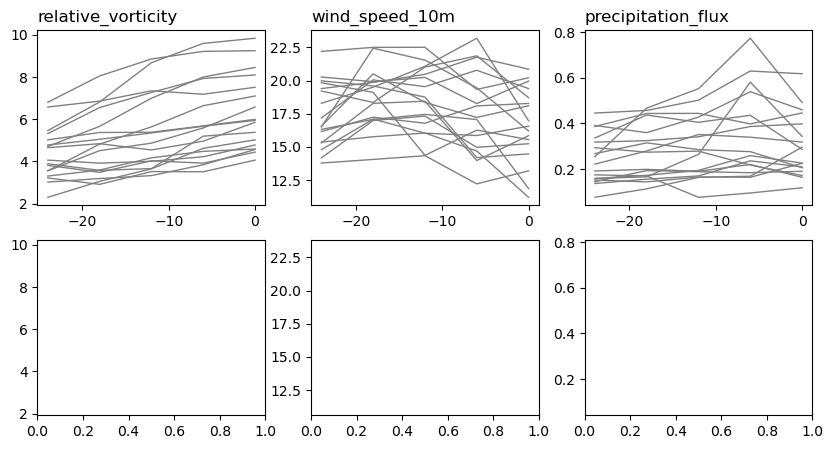

In [10]:
# Plot timeseries


########## Need to fix to handle new version of canari tracks with 360_day calendar

def plot_timeseries_combined_lines(case, tracks, tracks_ext):
    fig, axs = plt.subplots(3, 3, figsize=[10, 10])
    for col in axs.T:
        for ax in col[1:]:
            ax.sharey(col[0])
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    plot_timeseries(tracks[case]['ERA5'], settings[setting], axs=axs[0, :], color='0.5', label='All')
    plot_timeseries(tracks[case]['PRESENT'], settings[setting], axs=axs[1, :], color='0.5', label='All')
    plot_timeseries(tracks[case]['FUTURE'], settings[setting], axs=axs[2, :], color='0.5', label='All')
    plot_timeseries(tracks_ext[case]['ERA5'], settings[setting], axs=axs[0, :], color='r', label='Extreme')
    plot_timeseries(tracks_ext[case]['PRESENT'], settings[setting], axs=axs[1, :], color='r', label='Extreme')
    plot_timeseries(tracks_ext[case]['FUTURE'], settings[setting], axs=axs[2, :], color='r', label='Extreme')
    for i in range(3):
        plot_timeseries({1: target_track}, settings[setting], axs=axs[i, :], color='k')
    axs.flatten()[0].legend()
    fig.tight_layout()
    return fig, axs


def plot_timeseries_combined_percentiles(case, tracks, tracks_ext):
    fig, axs = plt.subplots(2, 3, figsize=[10, 5])
    for col in axs.T:
        for ax in col[1:]:
            ax.sharey(col[0])
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    plot_timeseries(tracks[case]['ERA5'], settings[setting], axs=axs[0, :], color='0.5', label=f'All ({len(tracks[case]['ERA5'])})')
    plot_timeseries(tracks[case]['PRESENT'], settings[setting], axs=axs[0, :], color='y', label=f'PRESENT ({len(tracks[case]['PRESENT'])})', plotstyle='percentiles')
    plot_timeseries(tracks[case]['FUTURE'], settings[setting], axs=axs[0, :], color='b', label=f'FUTURE ({len(tracks[case]['FUTURE'])})', plotstyle='percentiles')
    plot_timeseries(tracks_ext[case]['ERA5'], settings[setting], axs=axs[1, :], color='r', label=f'Extreme ({len(tracks_ext[case]['ERA5'])})')
    plot_timeseries(tracks_ext[case]['PRESENT'], settings[setting], axs=axs[1, :], color='y', label=f'PRESENT ({len(tracks_ext[case]['PRESENT'])})', plotstyle='percentiles')
    plot_timeseries(tracks_ext[case]['FUTURE'], settings[setting], axs=axs[1, :], color='b', label=f'FUTURE ({len(tracks_ext[case]['FUTURE'])})', plotstyle='percentiles')
    for i in range(2):
        plot_timeseries({1: target_track}, settings[setting], axs=axs[i, :], color='k')
    axs[0, 0].legend()
    axs[1, 0].legend()
    fig.tight_layout()
    return fig, axs

for case in cases_to_use:
    # plot_timeseries_combined_lines(case, flatten_mem_labels(tracks), flatten_mem_labels(tracks_ext))
    fig, axs = plot_timeseries_combined_percentiles(case, flatten_mem_labels(tracks), flatten_mem_labels(tracks_ext))
    fig.savefig(fdir / f'{case}_{setting}_timeseries.png')